In [4]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow joblib

  Using cached tensorflow-2.21.0-cp310-cp310-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.2.2-cp310-cp310-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
  Using cached keras-3.12.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached h5py-3.14.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [6]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1784281131.180676   14835 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784281132.061807   14835 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784281135.584364   14835 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
df = pd.read_csv("yahoo_stock.csv")
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [8]:
df.shape

(1825, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1825 non-null   object 
 1   High       1825 non-null   float64
 2   Low        1825 non-null   float64
 3   Open       1825 non-null   float64
 4   Close      1825 non-null   float64
 5   Volume     1825 non-null   float64
 6   Adj Close  1825 non-null   float64
dtypes: float64(6), object(1)
memory usage: 99.9+ KB


In [10]:
df.isnull().sum()

Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


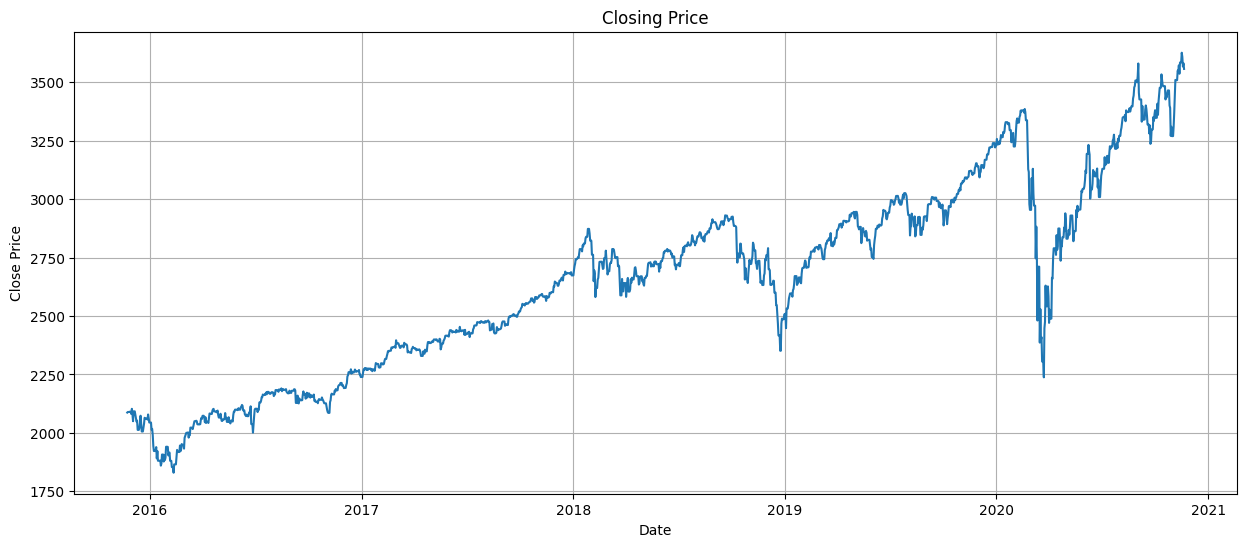

In [13]:
plt.figure(figsize=(15,6))
plt.plot(df["Date"], df["Close"])
plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

In [14]:
data = df[["Close"]]
data.head()

,Close
0,2086.590088
1,2089.139893
2,2088.870117
3,2088.870117
4,2090.110107


In [15]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
joblib.dump(scaler, "scaler.pkl")
scaled_data

array([[0.14323386],
       [0.14465213],
       [0.14450208],
       ...,
       [0.96711598],
       [0.97494769],
       [0.96141466]])

In [16]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

(1765, 60, 1)
(1765, 1)


In [17]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 1412
Testing Samples : 353


In [18]:
model = Sequential()

model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(60,1)
))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

model.summary()

E0000 00:00:1784281294.334632   14835 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [20]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [21]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0126 - mae: 0.0752 - val_loss: 0.0087 - val_mae: 0.0832
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0018 - mae: 0.0316 - val_loss: 0.0061 - val_mae: 0.0661
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0017 - mae: 0.0299 - val_loss: 0.0043 - val_mae: 0.0487
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0014 - mae: 0.0277 - val_loss: 0.0040 - val_mae: 0.0466
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0014 - mae: 0.0274 - val_loss: 0.0040 - val_mae: 0.0463
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0016 - mae: 0.0296 - val_loss: 0.0049 - val_mae: 0.0581
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0012 - mae: 0.0251 - val_loss: 0.0035 - val_mae: 0.0398
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0012 - mae: 0.0257 - val_loss: 0.0098 - val_mae: 0.0914
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - l

In [22]:
loss, mae = model.evaluate(X_test, y_test)
print("Loss :", loss)
print("MAE :", mae)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032 - mae: 0.0400
Loss : 0.0031727927271276712
MAE : 0.03995610773563385


In [24]:
predictions = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [25]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

In [26]:
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
print("MAE :", mae)
print("RMSE :", rmse)

MAE : 71.83430251859065
RMSE : 101.26735702924326


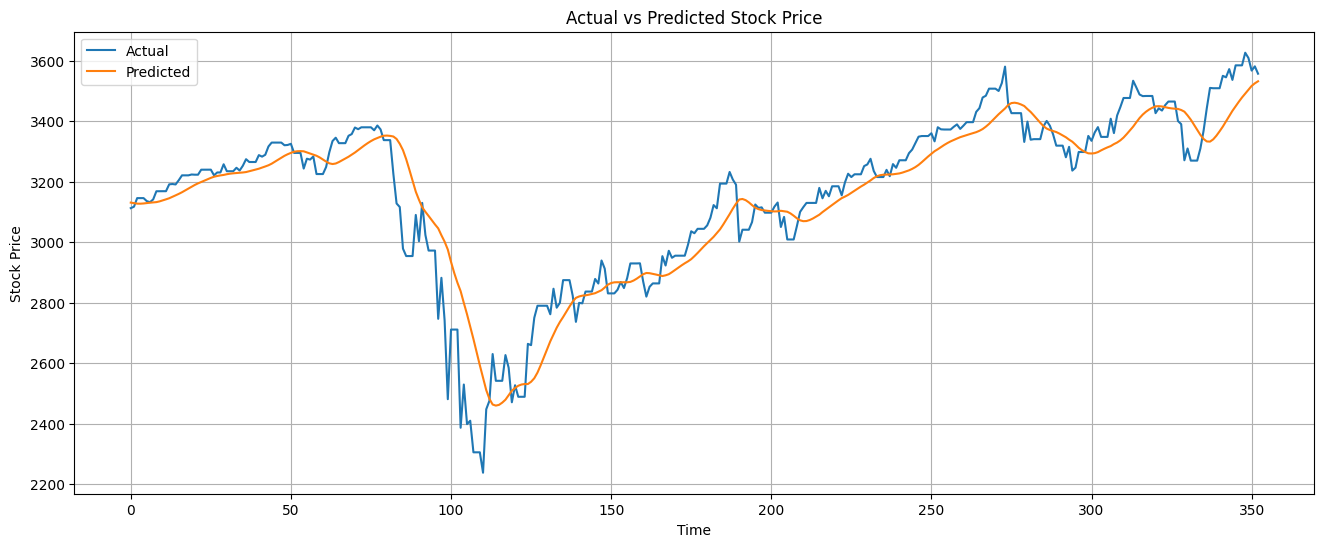

In [27]:
plt.figure(figsize=(16,6))
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
model.save("stock_lstm_model.keras")
print("Model Saved Successfully")

Model Saved Successfully
